In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [16]:
df=pd.read_csv("Employee.csv")
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [17]:
df.shape

(148, 6)

# 1. Data Exploration:

● Explore the data, list down the unique values in each feature and find its length.

In [18]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [19]:
for column in df.columns:
    print(column)
    print(df[column].unique())
   

Company
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Age
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Salary
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Place
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Country
['India']
Gender
[0 1]


In [20]:
for column in df.columns:
    print(column, ":", len(df[column].unique()))

Company : 7
Age : 30
Salary : 41
Place : 12
Country : 1
Gender : 2


● Perform the statistical analysis and renaming of the columns.

In [21]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [22]:
df.describe(include='all')

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [23]:
df.columns = df.columns.str.lower()
df.columns

Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')

# 2.Data Cleaning :

● Find the missing and inappropriate values, treat them appropriately.

● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   company  140 non-null    object 
 1   age      130 non-null    float64
 2   salary   124 non-null    float64
 3   place    134 non-null    object 
 4   country  148 non-null    object 
 5   gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [25]:
df.isnull().sum()

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

In [26]:
df[df.isnull().any(axis=1)]

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
5,Infosys,NaN,5000.0,Calcutta,India,0
6,TCS,NaN,6000.0,Chennai,India,1
10,CTS,23.0,NaN,Mumbai,India,0
12,CTS,45.0,NaN,Chennai,India,0
18,TCS,22.0,NaN,Chennai,India,0
19,Infosys,32.0,NaN,Mumbai,India,0
23,Infosys,NaN,5835.0,Cochin,India,0
24,TCS,NaN,7084.0,Chennai,India,1


In [27]:
for column in df.columns:
    print(column)
    print(df[column].unique())
    print()

company
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

age
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

salary
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

place
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

country
['India']

gender
[0 1]



In [28]:
df['age'] = df['age'].replace(0, np.nan)

In [29]:
df['salary'] = df['salary'].replace(1234, np.nan)

In [30]:
df["age"] = df["age"].fillna(df["age"].mean())


In [31]:
df["salary"] = df["salary"].fillna(df["salary"].mean())


In [32]:
df["company"] = df["company"].fillna(df["company"].mode()[0])


In [33]:
df["place"].fillna(df["place"].mode()[0],inplace=True)

● Remove all duplicate rows.

In [34]:
df.duplicated().sum()

np.int64(4)

In [35]:
df[df.duplicated()]

,company,age,salary,place,country,gender
84,CTS,43.000000,5448.416667,Mumbai,India,0
130,TCS,21.000000,4824.000000,Mumbai,India,0
131,Infosys,31.959677,5835.000000,Mumbai,India,0
144,Infosys,22.000000,8787.000000,Calcutta,India,1


In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df.shape

(144, 6)

● Find the outliers.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   company  144 non-null    object 
 1   age      144 non-null    float64
 2   salary   144 non-null    float64
 3   place    144 non-null    object 
 4   country  144 non-null    object 
 5   gender   144 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.9+ KB


In [39]:
q1=df["age"].quantile(0.25)
q3=df["age"].quantile(0.75)
print(f"Q1={q1} \nQ3={q3}")
IQR=q3-q1
print(IQR)
lower_limit=q1-1.5*IQR
upper_limit=q3-1.5*IQR
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outlier =[]
for i in df["age"]:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)
         

Q1=23.75 
Q3=36.0
12.25
Lower Limit: 5.375
Upper Limit: 54.375
[]


In [40]:
q1=df["salary"].quantile(0.25)
q3=df["salary"].quantile(0.75)
print(f"Q1{q1}\nQ3{q3}")
IQR=q3-q1
print(IQR)
lower_limit=q1-1.5*IQR
upper_limit=q3+1.5*IQR
print("Lower limit",lower_limit)
print("Upper limit",upper_limit)
outlier=[]
for i in df["salary"]:
    if i<lower_limit or i>upper_limit:
        outlier.append(i)
print(outlier)
#outliers = df[
#    (df["salary"] < lower_limit) |
#    (df["salary"] > upper_limit)
#]

#outliers


Q13184.0
Q37084.0
3900.0
Lower limit -2666.0
Upper limit 12934.0
[]


# 3. Data Analysis:

● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

In [41]:
filterd_df=df[(df["age"]>40)&(df["salary"]<5000)]
print(filterd_df)

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


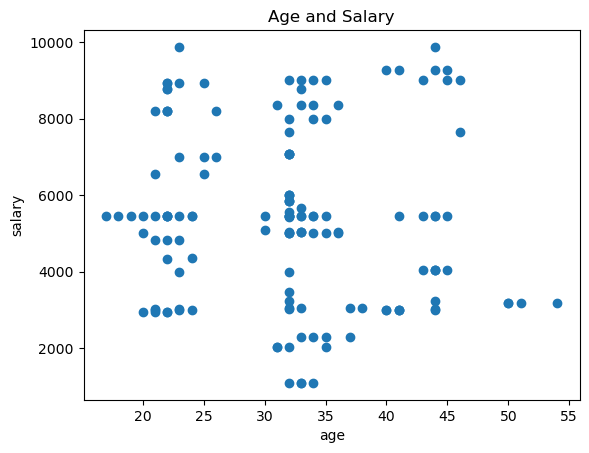

In [42]:
plt.scatter(df["age"],df["salary"])
plt.xlabel("age")
plt.ylabel("salary")
plt.title("Age and Salary")
plt.show()

In [43]:
place_count = df["place"].value_counts()
print(place_count)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


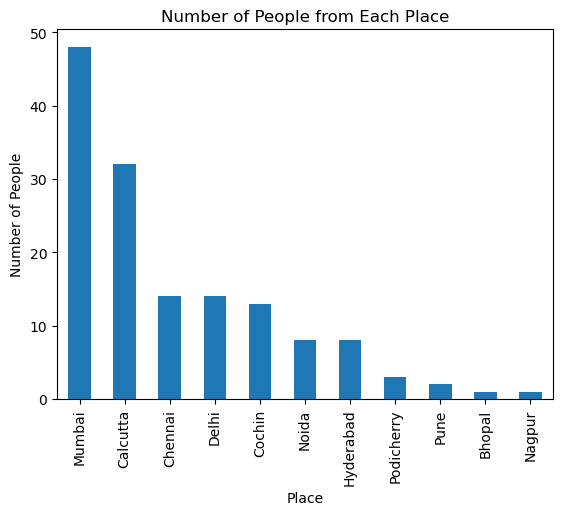

In [44]:
place_count.plot(kind="bar")
plt.xlabel("Place")
plt.ylabel("Number of People")
plt.title("Number of People from Each Place")
plt.show()

# 4. Data Encoding:

● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [45]:
df = pd.get_dummies(
    df,
    columns=["company", "place", "country"],
    dtype=int
)

In [46]:
df.dtypes

age                                  float64
salary                               float64
gender                                 int64
company_CTS                            int64
company_Congnizant                     int64
company_Infosys                        int64
company_Infosys Pvt Lmt                int64
company_TCS                            int64
company_Tata Consultancy Services      int64
place_Bhopal                           int64
place_Calcutta                         int64
place_Chennai                          int64
place_Cochin                           int64
place_Delhi                            int64
place_Hyderabad                        int64
place_Mumbai                           int64
place_Nagpur                           int64
place_Noida                            int64
place_Podicherry                       int64
place_Pune                             int64
country_India                          int64
dtype: object

# 5. Feature Scaling:

After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [47]:
# StandardScaler
standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(df)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=df.columns
)

print("Standard Scaled Data")
print(standard_df.head())


# MinMaxScaler
minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(df)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=df.columns
)

print("MinMax Scaled Data")
print(minmax_df.head())

Standard Scaled Data
        age    salary    gender  company_CTS  company_Congnizant  \
0 -1.465777  0.009536 -0.534522    -0.566658           -0.118678   
1 -0.247168  0.009536 -0.534522    -0.566658           -0.118678   
2  0.362136 -1.384722 -0.534522    -0.566658           -0.118678   
3  0.971441 -1.074731 -0.534522    -0.566658           -0.118678   
4 -1.100194 -0.631887 -0.534522    -0.566658           -0.118678   

   company_Infosys  company_Infosys Pvt Lmt  company_TCS  \
0        -0.652490                -0.118678     1.183216   
1         1.532592                -0.118678    -0.845154   
2        -0.652490                -0.118678     1.183216   
3         1.532592                -0.118678    -0.845154   
4        -0.652490                -0.118678     1.183216   

   company_Tata Consultancy Services  place_Bhopal  ...  place_Chennai  \
0                          -0.118678     -0.083624  ...       3.047247   
1                          -0.118678     -0.083624  ...      